# Amazon Customer Behavioral Analysis
### Scenario
Amazon’s marketing department wants to understand customer purchasing behavior and
improve customer retention strategies.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading dataset
df = pd.read_csv("Amazon Customer Behavior Survey.csv")
df

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
0,2023/06/04 1:28:19 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care,Yes,Few times a week,Keyword,Multiple pages,1,...,Sometimes,Yes,Occasionally,Yes,2,Yes,1,1,Competitive prices,Reducing packaging waste
1,2023/06/04 2:30:44 PM GMT+5:30,23,Female,Once a month,Clothing and Fashion,Yes,Few times a month,Keyword,Multiple pages,1,...,Rarely,No,Heavily,Yes,2,Sometimes,3,2,Wide product selection,Reducing packaging waste
2,2023/06/04 5:04:56 PM GMT+5:30,24,Prefer not to say,Few times a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,Keyword,Multiple pages,2,...,Rarely,No,Occasionally,No,4,No,3,3,Competitive prices,Product quality and accuracy
3,2023/06/04 5:13:00 PM GMT+5:30,24,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5,...,Sometimes,Yes,Heavily,Yes,3,Sometimes,3,4,Competitive prices,Product quality and accuracy
4,2023/06/04 5:28:06 PM GMT+5:30,22,Female,Less than once a month,Beauty and Personal Care;Clothing and Fashion,Yes,Few times a month,Filter,Multiple pages,1,...,Rarely,No,Heavily,Yes,4,Yes,2,2,Competitive prices,Product quality and accuracy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,2023/06/12 4:02:02 PM GMT+5:30,23,Female,Once a week,Beauty and Personal Care,Sometimes,Few times a week,categories,Multiple pages,4,...,Sometimes,Yes,Moderately,Sometimes,3,Sometimes,3,4,Competitive prices,Customer service responsiveness
598,2023/06/12 4:02:53 PM GMT+5:30,23,Female,Once a week,Clothing and Fashion,Sometimes,Few times a week,Filter,Multiple pages,3,...,Sometimes,Yes,Heavily,Sometimes,3,Sometimes,3,3,Product recommendations,Reducing packaging waste
599,2023/06/12 4:03:59 PM GMT+5:30,23,Female,Once a month,Beauty and Personal Care,Sometimes,Few times a week,categories,Multiple pages,3,...,Sometimes,Yes,Occasionally,Sometimes,3,Sometimes,2,3,Wide product selection,Product quality and accuracy
600,2023/06/12 9:57:20 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care;Clothing and Fashion;...,Yes,Few times a month,Keyword,Multiple pages,1,...,Sometimes,No,Heavily,Yes,2,Yes,2,2,Wide product selection,Product quality and accuracy


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Timestamp                               602 non-null    str  
 1   age                                     602 non-null    int64
 2   Gender                                  602 non-null    str  
 3   Purchase_Frequency                      602 non-null    str  
 4   Purchase_Categories                     602 non-null    str  
 5   Personalized_Recommendation_Frequency   602 non-null    str  
 6   Browsing_Frequency                      602 non-null    str  
 7   Product_Search_Method                   600 non-null    str  
 8   Search_Result_Exploration               602 non-null    str  
 9   Customer_Reviews_Importance             602 non-null    int64
 10  Add_to_Cart_Browsing                    602 non-null    str  
 11  Cart_Completion_Frequency     

### Tasks


- Required Visualizations
- Minimum 3:
    -  Countplot → Shopping frequency   
    - Pie Chart → Payment methods
    - Boxplot → Age vs Spending

1. Analyze:

- Customer shopping frequency
- Preferred shopping categories
- Device usage patterns

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Few times a month'),
  Text(1, 0, 'Less than once a month'),
  Text(2, 0, 'Once a week'),
  Text(3, 0, 'Once a month'),
  Text(4, 0, 'Multiple times a week')])

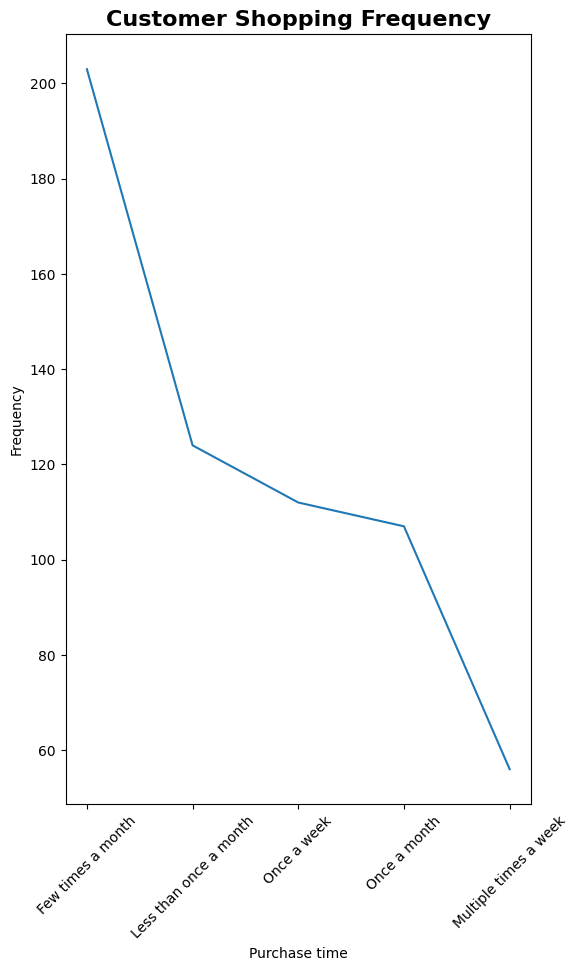

In [89]:
# Customer shopping frequency
shopping_frequency = df["Purchase_Frequency"].value_counts()
plt.figure(figsize=(6,10))
plt.plot(shopping_frequency)
plt.title("Customer Shopping Frequency",fontsize = 16,fontweight = "bold")
plt.xlabel("Purchase time")
plt.ylabel("Frequency")
plt.xticks(rotation = 45)

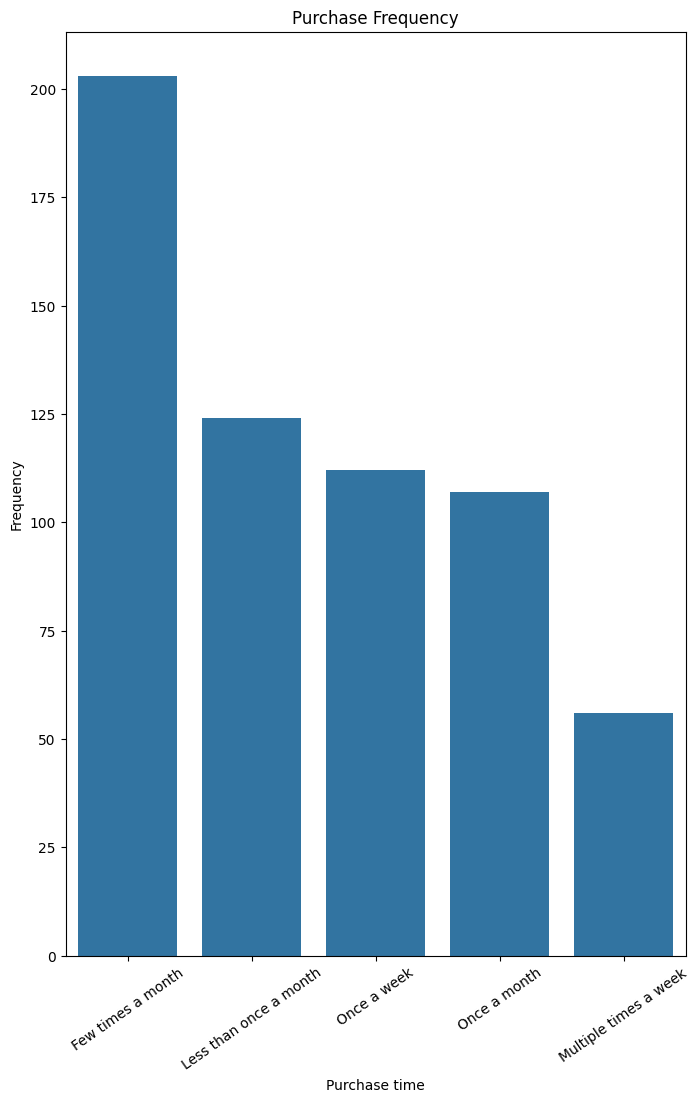

In [94]:
# Countplot
plt.figure(figsize=(8,12))
sns.countplot(df,x= "Purchase_Frequency",order=df["Purchase_Frequency"].value_counts().index)
plt.title("Purchase Frequency")
plt.xlabel("Purchase time")
plt.ylabel("Frequency")
plt.xticks(rotation = 35)
plt.show()


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Timestamp                               602 non-null    str  
 1   age                                     602 non-null    int64
 2   Gender                                  602 non-null    str  
 3   Purchase_Frequency                      602 non-null    str  
 4   Purchase_Categories                     602 non-null    str  
 5   Personalized_Recommendation_Frequency   602 non-null    str  
 6   Browsing_Frequency                      602 non-null    str  
 7   Product_Search_Method                   600 non-null    str  
 8   Search_Result_Exploration               602 non-null    str  
 9   Customer_Reviews_Importance             602 non-null    int64
 10  Add_to_Cart_Browsing                    602 non-null    str  
 11  Cart_Completion_Frequency     

In [ ]:
# Preferred shopping categories
preferred_categories = df["Purchase_Categories"].value_counts().idxmax()
preferred_categories

'Beauty and Personal Care'

In [96]:
# Device usage pattern
usage_pattern = df.groupby(by = "Browsing_Frequency")["Browsing_Frequency"].value_counts()
usage_pattern

Browsing_Frequency
Few times a month       199
Few times a week        249
Multiple times a day     77
Rarely                   77
Name: count, dtype: int64

2. Segment customers based on behavior.

In [98]:
segmented_customer = df.groupby(by = "Browsing_Frequency")[["Browsing_Frequency","Gender"]].value_counts()
segmented_customer

Browsing_Frequency    Gender           
Few times a month     Female               109
                      Prefer not to say     42
                      Male                  41
                      Others                 7
Few times a week      Female               154
                      Male                  64
                      Prefer not to say     25
                      Others                 6
Multiple times a day  Female                49
                      Prefer not to say     14
                      Male                  10
                      Others                 4
Rarely                Female                40
                      Male                  27
                      Prefer not to say      8
                      Others                 2
Name: count, dtype: int64

3. Identify patterns between:
    - Age vs spending behavior
    - Gender vs category preference
    

In [104]:
# segment on age vs spending behaviour
age_segmented_customer = df.groupby(by = "Browsing_Frequency")[["Browsing_Frequency","age"]].value_counts()

<Axes: ylabel='count'>

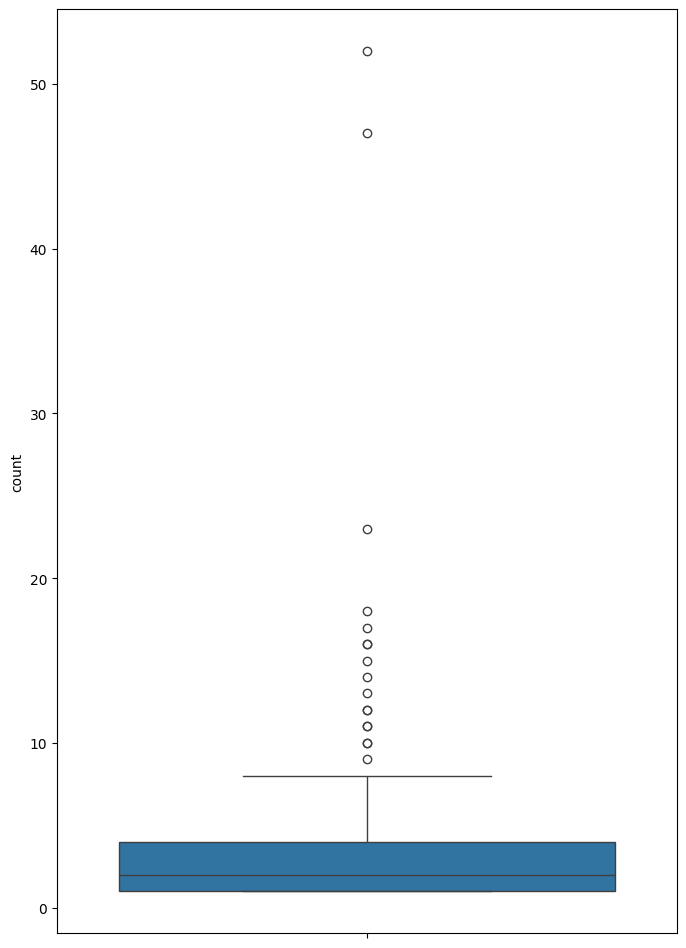

In [106]:
plt.figure(figsize=(8,12))
sns.boxplot(age_segmented_customer)

In [110]:
# gender v/s category prefrence
preferred_category = df.groupby(by="Gender")["Purchase_Categories"].value_counts()
preferred_category.groupby(by = "Gender").idxmax()

Gender
Female                          (Female, Beauty and Personal Care)
Male                                                (Male, others)
Others                          (Others, Beauty and Personal Care)
Prefer not to say    (Prefer not to say, Beauty and Personal Care)
Name: count, dtype: object

5. Provide marketing insights.

In [114]:
df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas
0,2023/06/04 1:28:19 PM GMT+5:30,23,Female,Few times a month,Beauty and Personal Care,Yes,Few times a week,Keyword,Multiple pages,1,...,Sometimes,Yes,Occasionally,Yes,2,Yes,1,1,Competitive prices,Reducing packaging waste
1,2023/06/04 2:30:44 PM GMT+5:30,23,Female,Once a month,Clothing and Fashion,Yes,Few times a month,Keyword,Multiple pages,1,...,Rarely,No,Heavily,Yes,2,Sometimes,3,2,Wide product selection,Reducing packaging waste
2,2023/06/04 5:04:56 PM GMT+5:30,24,Prefer not to say,Few times a month,Groceries and Gourmet Food;Clothing and Fashion,No,Few times a month,Keyword,Multiple pages,2,...,Rarely,No,Occasionally,No,4,No,3,3,Competitive prices,Product quality and accuracy
3,2023/06/04 5:13:00 PM GMT+5:30,24,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5,...,Sometimes,Yes,Heavily,Yes,3,Sometimes,3,4,Competitive prices,Product quality and accuracy
4,2023/06/04 5:28:06 PM GMT+5:30,22,Female,Less than once a month,Beauty and Personal Care;Clothing and Fashion,Yes,Few times a month,Filter,Multiple pages,1,...,Rarely,No,Heavily,Yes,4,Yes,2,2,Competitive prices,Product quality and accuracy


In [118]:
# Marketing Insights
df.groupby(by = "Gender")[["Purchase_Categories","Improvement_Areas"]].value_counts()

Gender             Purchase_Categories                                                    Improvement_Areas              
Female             Beauty and Personal Care                                               Customer service responsiveness    32
                   Clothing and Fashion                                                   Customer service responsiveness    23
                   Beauty and Personal Care                                               Reducing packaging waste           20
                   Clothing and Fashion                                                   Reducing packaging waste           20
                   Beauty and Personal Care                                               Product quality and accuracy       12
                                                                                                                             ..
Prefer not to say  Beauty and Personal Care;Home and Kitchen;others                       Customer service res


- Concepts Covered
    - Customer segmentation
    - Behavioral analytics
    - Feature analysis
    - Consumer insights